In [75]:
import argparse
import sys
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
from joblib import dump, load
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [77]:
def load_dataframe(path: Path) -> pd.DataFrame:
    """Read Excel (.xlsx) or CSV into a DataFrame, parse the TIME column."""
    if path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(path, engine="openpyxl", sheet_name="数据单")
    else:
        df = pd.read_csv(path)
    # Ensure TIME column exists
    if "TIME" not in df.columns:
        raise ValueError("Input file must contain a 'TIME' column.")
    df["TIME"] = pd.to_datetime(df["TIME"], errors="coerce")
    df = df.set_index("TIME")
    # Keep only numeric columns (isotopes)
    df = df.apply(pd.to_numeric, errors="coerce")
    # Drop columns/rows that are all‑NaN after coercion
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="any")
    return df


def fit_knn_model(
    X: np.ndarray,
    k: int = 5,
    metric: str = "euclidean",
    quantile: float = 0.95,
) -> Tuple[NearestNeighbors, float, StandardScaler]:
    """Fit scaler + k‑NN index and return model, threshold τ, scaler."""
    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)
    knn = NearestNeighbors(n_neighbors=k, metric=metric)
    knn.fit(X_scaled)
    dists, _ = knn.kneighbors(X_scaled)
    dk = dists[:, -1]  # kth neighbour distance per point
    tau = np.quantile(dk, quantile)
    return knn, tau, scaler


def score_knn(
    model: NearestNeighbors,
    X: np.ndarray,
    scaler: StandardScaler,
    tau: float,
    k: int = 5,
    metric: str = "euclidean",
) -> Tuple[np.ndarray, np.ndarray]:
    """Return distance to kth neighbour and boolean anomaly mask."""
    X_scaled = scaler.transform(X)
    dists, _ = model.kneighbors(X_scaled, n_neighbors=k)
    dk = dists[:, -1]
    return dk, dk > tau

def train_cmd(args: argparse.Namespace):
    df = load_dataframe(Path(args.input))
    X = df.values.astype("float32")
    model, tau, scaler = fit_knn_model(
        X,
        k=args.k,
        metric=args.metric,
        quantile=args.quantile,
    )
    # Persist everything
    params = {"tau": tau, "k": args.k, "metric": args.metric}
    dump((model, scaler, params), args.model_out)
    print(
        f"Model saved to {args.model_out}. Threshold τ = {tau:.4f}. "
        f"Training points = {len(df)}."
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    dk_all = []
    for train_idx, val_idx in kf.split(X):
        knn_cv, tau_cv, scaler_cv = fit_knn_model(X[train_idx], k=args.k,
                                                 metric=args.metric,
                                                 quantile=args.quantile)
        dk_val, _ = score_knn(knn_cv, X[val_idx], scaler_cv, tau_cv,
                              k=args.k, metric=args.metric)
        dk_all.extend(dk_val)
    plt.hist(dk_all, bins=40, density=True)
    plt.axvline(tau, ls='--')
    plt.title('Cross-validated k-distance distribution')
    plt.show()

def score_cmd(args: argparse.Namespace):
    model, scaler, params = load(args.model_in)
    tau = params["tau"]
    k = params["k"]
    metric = params["metric"]

    df = load_dataframe(Path(args.input))
    dk, is_anom = score_knn(model, df.values.astype("float32"), scaler, tau, k, metric)
    df_out = df.copy()
    df_out["knn_dist"] = dk
    df_out["is_anomaly"] = is_anom
    df_out.to_csv(args.out, index=True)
    num_anom = is_anom.sum()
    print(
        f"Scored {len(df_out)} rows — detected {num_anom} anomalies (τ = {tau:.4f}). "
        f"Results written to {args.out}."
    )


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="Fuel‑rod anomaly detection with k‑NN")
    sub = p.add_subparsers(required=False, dest="cmd")

    # Train
    t = sub.add_parser("train", help="train k‑NN model on normal data")
    t.add_argument("--input", default="./20230510-20240924.xlsx", help="Excel/CSV file containing normal history")
    t.add_argument("--model-out", default="knn_model.joblib", help="Output model file")
    t.add_argument("--k", type=int, default=5, help="Number of neighbours (default 5)")
    t.add_argument(
        "--metric", default="euclidean", help="Distance metric (default euclidean)"
    )
    t.add_argument(
        "--quantile", type=float, default=0.95, help="Tail quantile for τ (default 0.95)"
    )

    # Score
    s = sub.add_parser("score", help="score new data with an existing model")
    s.add_argument("input", help="Excel/CSV file with new measurements")
    s.add_argument("--model-in", required=True, help="Trained model file (.joblib)")
    s.add_argument("--out", default="scored.csv", help="CSV to write results")

    return p




C:\Users\nuomi\AppData\Local\Temp\ipykernel_16764\561944310.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TIME"] = pd.to_datetime(df["TIME"], errors="coerce")


Model saved to knn_model.joblib. Threshold τ = 4.4600. Training points = 469.


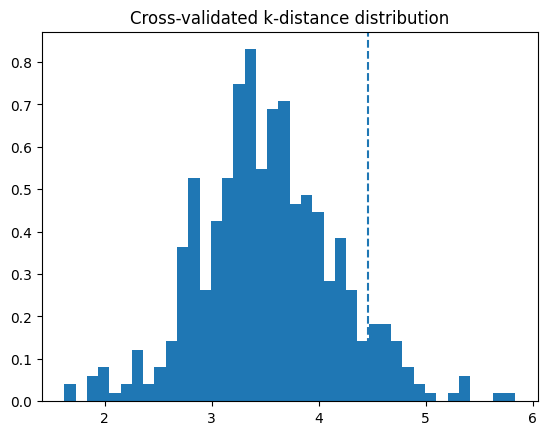

In [79]:
import sys
parser = build_parser()
args = parser.parse_args(["train"])

if args.cmd == "train":
    train_cmd(args)
elif args.cmd == "score":
    score_cmd(args)
else:
    parser.print_help()
    sys.exit(1)


In [63]:
df = pd.read_excel("./20230510-20240924.xlsx", sheet_name="数据单")

阈值（95th）：4.5481
检测到故障点数量：24 / 469


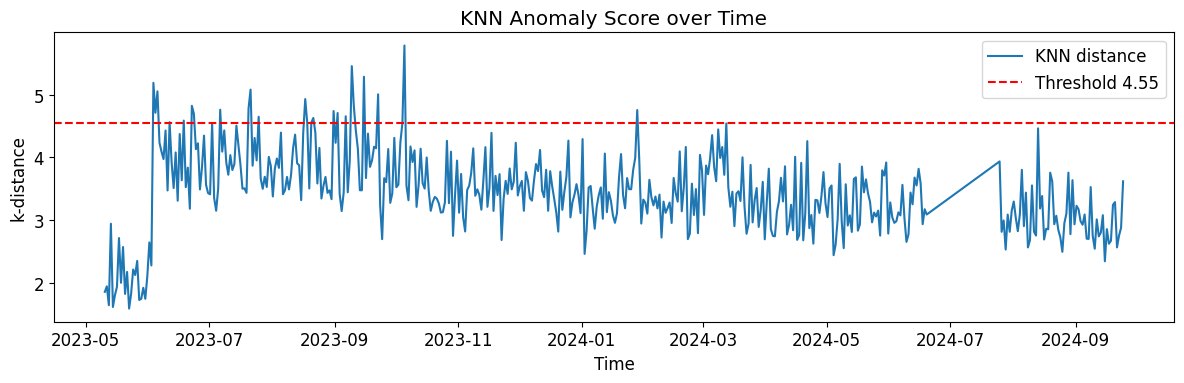


=== 故障点列表====
24    2023-06-03 12:00:00
25    2023-06-04 12:00:00
26    2023-06-05 12:00:00
32    2023-06-11 12:00:00
39    2023-06-18 12:00:00
43    2023-06-22 12:00:00
44    2023-06-23 12:00:00
57    2023-07-06 12:00:00
71    2023-07-20 12:00:00
72    2023-07-21 12:00:00
76    2023-07-25 12:00:00
99    2023-08-17 12:00:00
102   2023-08-20 12:00:00
103   2023-08-21 12:00:00
113   2023-08-31 12:00:00
115   2023-09-02 12:00:00
119   2023-09-06 12:00:00
122   2023-09-09 12:00:00
123   2023-09-10 12:00:00
128   2023-09-15 12:00:00
135   2023-09-22 12:00:00
147   2023-10-04 12:00:00
148   2023-10-05 12:00:00
263   2024-01-28 12:00:00
Name: TIME, dtype: datetime64[ns]


In [125]:
# ============================================================
# 0. 环境准备
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

# ============================================================
# 1. 数据加载
# ============================================================
# ---- 1.1 读取 CSV -----------------------------------------------------------

df_raw = pd.read_excel("./20230510-20240924.xlsx", sheet_name="数据单")

# ---- 1.2 解析时间列 ----------------------------------------------------------
df_raw.rename(columns={df_raw.columns[0]: 'TIME'}, inplace=True)
df_raw['TIME'] = pd.to_datetime(df_raw['TIME'], format='%Y年%m月%d日%H%M', errors='coerce')

# ---- 1.3 选 numeric 列 -------------------------------------------------------
numeric_cols = df_raw.columns.drop('TIME')
df_num = df_raw[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 若有 N/A，用 0 或列均值填充；此处用列均值
df_num = df_num.fillna(df_num.mean())

# ============================================================
# 2. 预处理：标准化
# ============================================================

# 2.3 标准化
scaler = StandardScaler()
X = scaler.fit_transform(df_num )

# ============================================================
# 3. KNN-based 无监督异常检测
# ============================================================
k = 5
nbrs = NearestNeighbors(n_neighbors=k+1)
nbrs.fit(X)
distances, _ = nbrs.kneighbors(X)
k_distance = distances[:, -1]         # 到第 k 个近邻的距离

# 阈值：95 分位；可换 99 分位或根据经验微调
threshold = np.percentile(k_distance, 95)

# 生成标签
labels = np.where(k_distance >= threshold, 'fault', 'normal')

# 摘要信息
print(f'阈值（95th）：{threshold:.4f}')
print(f'检测到故障点数量：{np.sum(labels=="fault")} / {len(labels)}')

# 将结果并回原始 DataFrame
df_result = df_raw.copy()
df_result['AnomalyScore'] = k_distance
df_result['Condition'] = labels

# ============================================================
# 4. 可视化结果
# ============================================================
plt.plot(df_result['TIME'], df_result['AnomalyScore'], label='KNN distance')
plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold {threshold:.2f}')
plt.title('KNN Anomaly Score over Time')
plt.xlabel('Time')
plt.ylabel('k-distance')
plt.legend()
plt.tight_layout()
plt.show()

faults = df_result[df_result['Condition'] == 'fault']
print('\n=== 故障点列表====')
print(faults["TIME"])

IsoForest 阈值（95th）：0.5663
检测到故障点数量：24 / 469


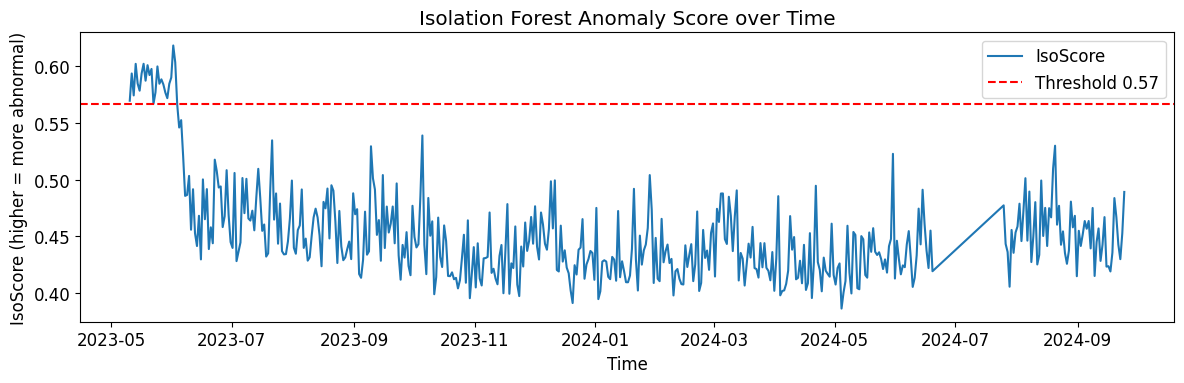


=== 故障点列表（TIME） ===
0    2023-05-10 12:00:00
1    2023-05-11 12:00:00
2    2023-05-12 12:00:00
3    2023-05-13 12:00:00
4    2023-05-14 12:00:00
5    2023-05-15 12:00:00
6    2023-05-16 12:00:00
7    2023-05-17 12:00:00
8    2023-05-18 12:00:00
9    2023-05-19 12:00:00
10   2023-05-20 12:00:00
11   2023-05-21 12:00:00
12   2023-05-22 12:00:00
13   2023-05-23 12:00:00
14   2023-05-24 12:00:00
15   2023-05-25 12:00:00
16   2023-05-26 12:00:00
17   2023-05-27 12:00:00
18   2023-05-28 12:00:00
19   2023-05-29 12:00:00
20   2023-05-30 12:00:00
21   2023-05-31 12:00:00
22   2023-06-01 12:00:00
23   2023-06-02 12:00:00
Name: TIME, dtype: datetime64[ns]


In [133]:
# ============================================================
# 3. Isolation Forest 无监督异常检测（修正版）
# ============================================================
from sklearn.ensemble import IsolationForest

# 3.1 训练 Isolation Forest
#    contamination=0.05 => 期望 5% 样本为异常，
#    若想更严格可调小，如 0.02；想更敏感调大。
iso = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42,
        n_jobs=-1
     )
iso.fit(X)

# 3.2 取得“异常分数”
#    score_samples/decision_function：正常>0，异常<0
#    为了直觉统一（分数越大越异常），取相反数：
raw_score   = iso.score_samples(X)          # 正常高、异常低
iso_score   = -raw_score                    # 现在：异常高、正常低

# 3.3 计算阈值（95 分位 = contamination 对应分位）
threshold = np.percentile(iso_score, 95)    # or 100*(1-contam)

# 3.4 生成标签
labels = np.where(iso_score >= threshold, 'fault', 'normal')

# 3.5 摘要
print(f'IsoForest 阈值（95th）：{threshold:.4f}')
print(f'检测到故障点数量：{np.sum(labels == "fault")} / {len(labels)}')

# 3.6 将结果保存
df_result2 = df_raw.copy()
df_result2['IsoScore']  = iso_score
df_result2['Condition'] = labels

# ============================================================
# 4. 可视化结果
# ============================================================
plt.plot(df_result2['TIME'], df_result2['IsoScore'], label='IsoScore')
plt.axhline(threshold, color='r', linestyle='--',
            label=f'Threshold {threshold:.2f}')
plt.title('Isolation Forest Anomaly Score over Time')
plt.xlabel('Time')
plt.ylabel('IsoScore (higher = more abnormal)')
plt.legend()
plt.tight_layout()
plt.show()

faults2 = df_result2[df_result2['Condition'] == 'fault']
print('\n=== 故障点列表（TIME） ===')
print(faults2['TIME'].reset_index(drop=True))

In [119]:
np.percentile(scores,  95)

0.16195723161453437